<a href="https://colab.research.google.com/github/cgm2179/indoor-walk-test/blob/main/Physics%20Engine/2D/SIM%20V3/Outdoor%20V3%20Sim/SIM%20V3_Outdoor_Phase_BCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIM V3 · Outdoor · Phase B + C + D — one run
**Directional** outdoor surrogate driven by **real base stations on real buildings** (`fw_bs_catalog`): building-mounted panel/sector sources, 10-channel input (the 9 material/Tx/freq channels + a directivity channel), held-out real station (**Forte Hall**) for g2. Same one-session, local-disk, CuPy+AMP flow as indoor. Pick a **GPU runtime**.

### 1 · Clone the repo + mount Drive

In [9]:
# /content is wiped on every runtime restart, so (re)clone the code here.
import os, getpass
REPO_ROOT = '/content/indoor-walk-test'
if not os.path.isdir(os.path.join(REPO_ROOT, 'Physics Engine')):
    tok = getpass.getpass('GitHub token (repo read): ')
    os.system(f'git clone --depth 1 https://{tok}@github.com/cgm2179/indoor-walk-test.git "{REPO_ROOT}"')
try:
    from google.colab import drive; drive.mount('/content/drive')   # only for the final save
except ModuleNotFoundError:
    pass
print('repo present:', os.path.isdir(os.path.join(REPO_ROOT, 'Physics Engine', '2D', 'SIM V3')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
repo present: True


### 2 · Put SIM V3 on the path

In [10]:
import sys, os
SIMV3 = os.path.join(REPO_ROOT, 'Physics Engine', '2D', 'SIM V3')
assert os.path.exists(os.path.join(SIMV3, '_bootstrap.py')), f'clone missing — re-run cell 1: {SIMV3}'
sys.path.insert(0, SIMV3); os.chdir(SIMV3)
import torch; print('SIM V3 =', SIMV3, '| torch', torch.__version__, '| cuda', torch.cuda.is_available())

SIM V3 = /content/indoor-walk-test/Physics Engine/2D/SIM V3 | torch 2.11.0+cu128 | cuda True


### 3 · Build the georeferenced NoMa city grid (from the committed OBJ)
The city grid is gitignored (~360 MB), so build it here from `Data/models/NoMa_DC/NoMa_DC_buildings.obj` (~1–3 min, once per runtime). `load_georef_city` injects the FCC-HQ anchor in-memory, so no separate patch step.

In [11]:
import subprocess, sys, _bootstrap as B
grid_npy = B.CITY_DIR / 'material_grid.npy'
if not grid_npy.exists():
    subprocess.run([sys.executable, str(B.SIM3D / 'voxelize_city.py'), '--no-preview'],
                   cwd=REPO_ROOT, check=True)                 # add --bbox-lonlat -77.0144 38.900 -77.0005 38.908 to crop/speed up
print('city grid ready:', grid_npy.exists(), '->', grid_npy)

city grid ready: True -> /content/indoor-walk-test/Physics Engine/3D Map Physics/SIM V1 3D/city/NoMa_DC_buildings/material_grid.npy


### 4 · Parameters (cellular bands with real stations; Forte Hall held out)

In [12]:
BANDS = ['TMO_B71_617', 'ATT/TMO/VZW_B12/B13/B14_746', 'VZW_B5/B26_885',
         'ATT/TMO/VZW_B2_1965', 'ATT/TMO/VZW_B4/B65/B66_2160', 'ATT_B30_2355',
         'TMO_n41_2508', 'VZW_n77/n78_3710', 'VZW_n77_3809', 'WLAN_WiFi_2442']
#   Network_Band(s)_Freq · every band a station picked up, grouped only within 30 MHz
#   (slashes = lumped). 9 cellular clusters (4G+5G) + artificial WLAN = one FDTD each.
HOLDOUT = None                  # None = train on ALL 6 stations (BS2-BS7)
VAL_SITE = 'BS7_forte_hall'     # station for the Phase-D g2 check (in-sample when HOLDOUT=None)
ANTENNA_KINDS = ['panel', 'dish', 'yagi', 'lpda', 'horn', 'slot', 'patch', 'loop', 'fractal']  # 2D antenna waveforms
OUT   = '/content/fw_data_bs'
CKPT  = '/content/fw_bs.pt'
EPOCHS, BASE, BATCH = 80, 32, 16
BOXES_PER_STATION = 16          # 24 (site,band) x 9 antennas x 16 boxes ~ 3.5k samples
MAX_CELLS = 6_000_000           # A100; on T4 use ~1_600_000
CITY_DIR = None                 # None = committed OBJ grid; REPO '.../SIM V1 3D/city/NoMa_DC_osm' for real OSM


### 4c · Use the REAL OSM city grid (aligned to true lon/lat)
The BlenderGIS OBJ model is simplified and can look mis-registered vs OSM. `voxelize_gpkg` places every building at its real lon/lat, so base stations land on the correct blocks. This builds it from `building.032010.gpkg` if present and points `CITY_DIR` at it; otherwise it falls back to the committed OBJ grid.

In [13]:
import os, subprocess, sys, shutil, _bootstrap as B
USE_OSM = True                       # set False to force the committed OBJ grid
# Prefer a full uploaded gpkg (any bbox); else the small NoMa clip committed to the repo (no upload needed).
CLIP = str(B.SIM3D / 'city_src' / 'NoMa_DC_buildings.gpkg')
GPKG = next((p for p in ['/content/drive/MyDrive/building.032010.gpkg',
                         '/content/building.032010.gpkg',
                         os.path.expanduser('~/Downloads/building.032010.gpkg'),
                         CLIP] if os.path.exists(p)), None)
OSM_DIR = str(B.SIM3D / 'city' / 'NoMa_DC_osm')
if USE_OSM and GPKG:
    if not os.path.exists(os.path.join(OSM_DIR, 'material_grid.npy')):
        os.makedirs(OSM_DIR, exist_ok=True)
        subprocess.run(['pip','-q','install','geopandas','pyogrio','shapely'])
        # real terrain: try the free Terrarium DEM; else use the committed NoMa DEM; else flat
        dem = os.path.join(OSM_DIR, 'dem.npy'); terr = []
        try:
            subprocess.run([sys.executable, str(B.SIM3D/'fetch_dem_terrarium.py'),
                            '--city-dir', str(B.CITY_DIR), '--out', dem], check=True)
            terr = ['--terrain', dem]
        except Exception as e:
            committed = str(B.SIM3D / 'city_src' / 'dem_noma.npy')
            if os.path.exists(committed):
                shutil.copy(committed, dem); terr = ['--terrain', dem]
                print('DEM fetch failed; using committed NoMa DEM:', e)
            else:
                print('DEM skipped (flat ground):', e)
        subprocess.run([sys.executable, str(B.SIM3D/'voxelize_gpkg.py'), '--gpkg', GPKG,
                        '--material-model','penetrable','--foliage','--ground', *terr,
                        '--no-preview'], check=True)
    CITY_DIR = OSM_DIR
    print('CITY_DIR = real OSM grid (penetrable concrete+glass · foliage · terrain) ->', CITY_DIR)
    print('   built from', ('committed NoMa clip' if GPKG == CLIP else GPKG))
else:
    CITY_DIR = None
    print('OSM disabled -> committed OBJ grid')


OSM disabled -> committed OBJ grid


# ---- Map + CRS of the grid the Dataset & U-Net see (all 6 stations · 4G/5G/WLAN · antennas) ----
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict
import _bootstrap as B, voxelize_city as VC, city_georef as CG
import fw_bs_catalog as fbs
from bands_v3 import get

grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)     # CITY_DIR=None -> committed OBJ grid
cs = float(man['cell_size_m']); NX, NY, NZ = grid.shape
corners = [VC.vox_to_lonlat(man, vx, vz) for vx in (0, NX) for vz in (0, NZ)]
lons = [c[0] for c in corners]; lats = [c[1] for c in corners]
sb = defaultdict(set)
for s in sts:
    sb[s['site']].add(s['band'])
n_fields = len(fbs._dedupe_by_site(sts))

print("CRS / georeference (every lon/lat <-> voxel uses this):")
print(f"  EPSG:{man['epsg']} Web-Mercator · anchor = FCC HQ {CG.FCC_LONLAT}")
print(f"  merc_anchor = {[round(a,1) for a in man['merc_anchor']]}  merc_scale = {man.get('merc_scale')}")
print(f"  cell = {cs} m · grid {NX}x{NY}x{NZ} vox · {NX*cs:.0f} x {NZ*cs:.0f} m · "
      f"buildings = {'real OSM' if CITY_DIR else 'OBJ'}")
print(f"  bbox lon/lat  [{min(lons):.5f}, {min(lats):.5f}]  ..  [{max(lons):.5f}, {max(lats):.5f}]")
print(f"\nDataset = {len(sb)} stations x {n_fields} (site,band) fields x {len(ANTENNA_KINDS)} antenna "
      f"waveforms = {n_fields*len(ANTENNA_KINDS)} shards")
for b in BANDS:
    ss = sorted({s['site'].split('_')[0] for s in sts if s['band'] == b})
    print(f"   {b:14} {get(b).f_mhz:6.0f} MHz {get(b).family:4} : {ss or '(no station)'}")
print(f"   antenna waveforms: {ANTENNA_KINDS}")

# y=2 building slice = exactly the plane bs_region crops each Tx region from
plane = np.asarray(grid[:, 2, :]) == 3
fig, ax = plt.subplots(figsize=(12, 12 * NZ / NX))
ax.imshow(plane.T, origin='lower', cmap='Greys', extent=[0, NX*cs, 0, NZ*cs], alpha=.9)
fx, fz = VC.lonlat_to_vox(man, *CG.FCC_LONLAT)
ax.plot(fx*cs, fz*cs, 'k^', ms=13, zorder=8)
done = set()
for s in sts:
    if s['site'] in done:
        continue
    done.add(s['site'])
    fams = {get(bb).family for bb in sb[s['site']]}
    c = 'deepskyblue' if 'WLAN' in fams else ('orange' if s['site'] == VAL_SITE else 'lime')
    ax.plot(s['vx']*cs, s['vz']*cs, '*', color=c, ms=17, mec='k', zorder=6)
    th = np.radians(s['boresight'])                       # boresight arrow (X=west+, Z=north+)
    ax.arrow(s['vx']*cs, s['vz']*cs, -np.sin(th)*90, np.cos(th)*90,
             color='k', head_width=18, length_includes_head=True, zorder=5)
    bl = ' '.join(sorted({bb.split('_')[-1] for bb in sb[s['site']]}))
    ax.text(s['vx']*cs+10, s['vz']*cs+8, f"{s['site'].split('_')[0]} · {bl}", fontsize=7.5, zorder=7)
leg = [Line2D([0],[0], marker='^', color='w', mfc='k', label='FCC HQ (walk Rx)', ms=10),
       Line2D([0],[0], marker='*', color='w', mfc='lime', mec='k', label='cellular Tx (train)', ms=13),
       Line2D([0],[0], marker='*', color='w', mfc='orange', mec='k', label=f'g2 check ({VAL_SITE.split("_")[0]})', ms=13),
       Line2D([0],[0], marker='*', color='w', mfc='deepskyblue', mec='k', label='WLAN AP (artificial)', ms=13)]
ax.legend(handles=leg, loc='upper right')
ax.set_title(f"Grid the dataset & U-Net see · {'OSM' if CITY_DIR else 'OBJ'} buildings (class 3 = barrier) · "
             f"EPSG:{man['epsg']}\n6 stations x 4G/5G/WLAN bands x {len(ANTENNA_KINDS)} antenna waveforms "
             f"(arrow = boresight)")
ax.set_xlabel('X  (m, west +)'); ax.set_ylabel('Z  (m, north +)')
plt.tight_layout(); plt.show()


CRS / georeference (every lon/lat <-> voxel uses this):
  EPSG:3857 Web-Mercator · anchor = FCC HQ (-77.0074055, 38.90358466666667)
  merc_anchor = [8572425.2, 4707870.3]  merc_scale = 0.778243
  cell = 1.0 m · grid 2768x74x1776 vox · 2768 x 1776 m · buildings = OBJ
  bbox lon/lat  [-77.02269, 38.89631]  ..  [-76.99074, 38.91226]

Dataset = 7 stations x 34 (site,band) fields x 9 antenna waveforms = 306 shards
   TMO_B71_617       617 MHz 4G   : ['BS1', 'BS2', 'BS6']
   ATT/TMO/VZW_B12/B13/B14_746    746 MHz 4G   : ['BS1', 'BS2', 'BS5', 'BS6', 'BS7']
   VZW_B5/B26_885    885 MHz 4G   : ['BS1', 'BS2', 'BS7']
   ATT/TMO/VZW_B2_1965   1965 MHz 4G   : ['BS1', 'BS2', 'BS5', 'BS6']
   ATT/TMO/VZW_B4/B65/B66_2160   2160 MHz 4G   : ['BS1', 'BS2', 'BS4', 'BS5', 'BS6', 'BS7']
   ATT_B30_2355     2355 MHz 4G   : ['BS1', 'BS5', 'BS6']
   TMO_n41_2508     2508 MHz 5G   : ['BS1', 'BS2', 'BS4', 'BS6']
   VZW_n77/n78_3710   3710 MHz 5G   : ['BS1', 'BS7']
   VZW_n77_3809     3809 MHz 5G   : ['BS1', 'BS7

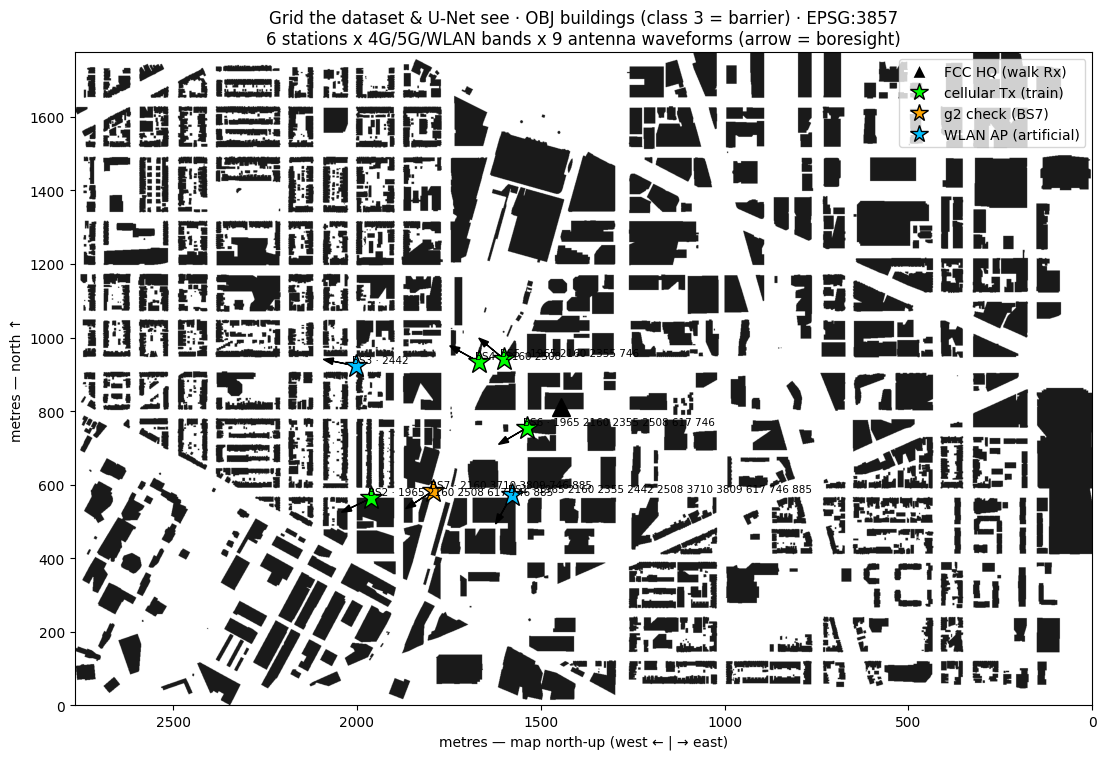

In [14]:
# ---- Map + CRS of the grid the Dataset & U-Net see (all 6 stations · 4G/5G/WLAN · antennas) ----
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict
import _bootstrap as B, voxelize_city as VC, city_georef as CG
import fw_bs_catalog as fbs
from bands_v3 import get

grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)     # CITY_DIR=None -> committed OBJ grid
cs = float(man['cell_size_m']); NX, NY, NZ = grid.shape
corners = [VC.vox_to_lonlat(man, vx, vz) for vx in (0, NX) for vz in (0, NZ)]
lons = [c[0] for c in corners]; lats = [c[1] for c in corners]
sb = defaultdict(set)
for s in sts:
    sb[s['site']].add(s['band'])
n_fields = len(fbs._dedupe_by_site(sts))

print("CRS / georeference (every lon/lat <-> voxel uses this):")
print(f"  EPSG:{man['epsg']} Web-Mercator · anchor = FCC HQ {CG.FCC_LONLAT}")
print(f"  merc_anchor = {[round(a,1) for a in man['merc_anchor']]}  merc_scale = {man.get('merc_scale')}")
print(f"  cell = {cs} m · grid {NX}x{NY}x{NZ} vox · {NX*cs:.0f} x {NZ*cs:.0f} m · "
      f"buildings = {'real OSM' if CITY_DIR else 'OBJ'}")
print(f"  bbox lon/lat  [{min(lons):.5f}, {min(lats):.5f}]  ..  [{max(lons):.5f}, {max(lats):.5f}]")
print(f"\nDataset = {len(sb)} stations x {n_fields} (site,band) fields x {len(ANTENNA_KINDS)} antenna "
      f"waveforms = {n_fields*len(ANTENNA_KINDS)} shards")
for b in BANDS:
    ss = sorted({s['site'].split('_')[0] for s in sts if s['band'] == b})
    print(f"   {b:14} {get(b).f_mhz:6.0f} MHz {get(b).family:4} : {ss or '(no station)'}")
print(f"   antenna waveforms: {ANTENNA_KINDS}")

# y=2 building slice = exactly the plane bs_region crops each Tx region from
plane = np.asarray(grid[:, 2, :]) == 3
fig, ax = plt.subplots(figsize=(12, 12 * NZ / NX))
ax.imshow(plane.T, origin='lower', cmap='Greys', extent=[0, NX*cs, 0, NZ*cs], alpha=.9)
fx, fz = VC.lonlat_to_vox(man, *CG.FCC_LONLAT)
ax.plot(fx*cs, fz*cs, 'k^', ms=13, zorder=8)
done = set()
for s in sts:
    if s['site'] in done:
        continue
    done.add(s['site'])
    fams = {get(bb).family for bb in sb[s['site']]}
    c = 'deepskyblue' if 'WLAN' in fams else ('orange' if s['site'] == VAL_SITE else 'lime')
    ax.plot(s['vx']*cs, s['vz']*cs, '*', color=c, ms=17, mec='k', zorder=6)
    th = np.radians(s['boresight'])                       # boresight arrow (X=west+, Z=north+)
    ax.arrow(s['vx']*cs, s['vz']*cs, -np.sin(th)*90, np.cos(th)*90,
             color='k', head_width=18, length_includes_head=True, zorder=5)
    bl = ' '.join(sorted({bb.split('_')[-1] for bb in sb[s['site']]}))
    ax.text(s['vx']*cs+10, s['vz']*cs+8, f"{s['site'].split('_')[0]} · {bl}", fontsize=7.5, zorder=7)
leg = [Line2D([0],[0], marker='^', color='w', mfc='k', label='FCC HQ (walk Rx)', ms=10),
       Line2D([0],[0], marker='*', color='w', mfc='lime', mec='k', label='cellular Tx (train)', ms=13),
       Line2D([0],[0], marker='*', color='w', mfc='orange', mec='k', label=f'g2 check ({VAL_SITE.split("_")[0]})', ms=13),
       Line2D([0],[0], marker='*', color='w', mfc='deepskyblue', mec='k', label='WLAN AP (artificial)', ms=13)]
ax.legend(handles=leg, loc='upper right')
ax.set_title(f"Grid the dataset & U-Net see · {'OSM' if CITY_DIR else 'OBJ'} buildings (class 3 = barrier) · "
             f"EPSG:{man['epsg']}\n6 stations x 4G/5G/WLAN bands x {len(ANTENNA_KINDS)} antenna waveforms "
             f"(arrow = boresight)")
ax.invert_xaxis()   # grid X is west-positive; flip so the map is north-up / east-right like OSM
ax.set_xlabel('metres — map north-up (west ← | → east)'); ax.set_ylabel('metres — north ↑')
plt.tight_layout(); plt.show()


### 5 · GPU acceleration (CuPy) — accelerates the base-station FDTD too
Same cell as indoor: it patches `fw_dataset._run_field`, which `fw_bs_catalog.bs_field` calls, so outdoor generation runs on the GPU unchanged.

In [15]:
# --- GPU FDTD (CuPy): reuse FullWaveScene setup, run only the time loop on GPU ---
import numpy as np, math
import fw_dataset
from fullwave2d import FullWaveScene

C0 = 299_792_458.0
_cpu_run_field = fw_dataset._run_field          # keep original (fallback + parity check)

USE_GPU = False
try:
    import cupy as cp
    USE_GPU = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    try:  # Colab GPU runtime usually ships CuPy; install the CUDA-12 wheel if not
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'cupy-cuda12x'], check=True)
        import cupy as cp
        USE_GPU = cp.cuda.runtime.getDeviceCount() > 0
    except Exception as e:
        print('CuPy unavailable -> staying on CPU:', e)

def _laplacian_gpu(u, inv_h2):                  # matches Spatial_Physics.laplacian (np.roll)
    lap = cp.zeros_like(u)
    for ax in range(u.ndim):
        lap += cp.roll(u, 1, axis=ax) + cp.roll(u, -1, axis=ax)
    lap -= 2.0 * u.ndim * u
    return lap * inv_h2

def _run_field_gpu(classes, h, tx_ij, f_mhz, crossings):
    sim = FullWaveScene(classes, h, f_mhz, tx_ij, source='cw')     # identical CPU setup
    steps = int(round(crossings * max(classes.shape) * h / C0 / sim.dt))
    dt, f0 = sim.dt, sim.f0
    omega = 2.0 * np.pi * f0
    inv_h2 = float(sim.inv_h2)
    u      = cp.asarray(sim.u)                  # move only the fields the loop touches
    u_prev = cp.asarray(sim.u_prev)
    cdt2   = cp.asarray(sim.cdt2)
    inv1pa = cp.asarray(sim._inv1pa)
    _1ma   = cp.asarray(sim._1ma)
    damp   = cp.asarray(sim.damp)
    rigid  = cp.asarray(sim.rigid)
    src    = sim.src_idx
    warmup = int(0.6 * steps)                   # same as _run_field's simulate() call
    period_steps = max(1, int(round((1.0 / f0) / dt)))
    win_start = max(warmup, steps - 2 * period_steps)             # phasor_periods = 2
    acc = cp.zeros(u.shape, cp.complex128); n_win = 0
    for k in range(steps):                      # mirrors FullWaveScene.step() exactly
        lap = _laplacian_gpu(u, inv_h2)
        u_next = (2.0 * u - _1ma * u_prev + cdt2 * lap) * inv1pa
        u_next[src] += math.sin(omega * (k * dt))                # cw() soft source, t=k*dt
        u_next[rigid] = 0.0                     # perfect reflectors
        u_next *= damp                          # absorbing sponge
        u_prev = u * damp
        u = u_next
        if k >= win_start:                      # on-the-fly single-freq DFT (u at (k+1)dt)
            acc += u * complex(np.exp(-1j * omega * (k + 1) * dt))
            n_win += 1
    if not bool(cp.isfinite(u).all()):
        raise FloatingPointError('field blew up (GPU)')
    return cp.asnumpy((2.0 / max(n_win, 1)) * acc)               # complex phasor U, on CPU

if USE_GPU:
    fw_dataset._run_field = _run_field_gpu       # generate() -> _indoor_field -> this
    name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    # parity vs CPU on a tiny field so you can trust the port
    rng = np.random.default_rng(0)
    test = ((rng.random((96, 96)) < 0.12).astype(np.int8) * 2)   # sparse concrete
    Ucpu = _cpu_run_field(test, 0.06, (48, 48), 617.0, 1.2)
    Ugpu = _run_field_gpu(test, 0.06, (48, 48), 617.0, 1.2)
    rel = float(np.abs(Ugpu - Ucpu).max() / (np.abs(Ucpu).max() + 1e-30))
    print(f'GPU FDTD ON -> {name} | parity max|dU|/|U| = {rel:.2e} (want < 1e-6)')
else:
    print('GPU FDTD OFF -> CPU _run_field (pick a GPU runtime for the speed-up).')


GPU FDTD ON -> NVIDIA A100-SXM4-40GB | parity max|dU|/|U| = 0.00e+00 (want < 1e-6)


### 6 · Phase B — generate from real base stations (directional FDTD)

In [16]:
import fw_bs_catalog as fbs
fbs.generate_bs(BANDS, holdout_site=HOLDOUT, boxes_per_station=BOXES_PER_STATION,
                out_dir=OUT, max_cells=MAX_CELLS, seed=1, city_dir=CITY_DIR,
                antenna_kinds=ANTENNA_KINDS)   # one omni FDTD per (site,band) x each antenna pattern


train sites: ['BS7_forte_hall', 'BS7_forte_hall', 'BS7_forte_hall', 'BS7_forte_hall', 'BS7_forte_hall', 'BS2_900_nj_ave', 'BS4_55_m_st', 'BS4_55_m_st', 'BS5_1140_n_capitol', 'BS5_1140_n_capitol', 'BS6_1005_n_capitol', 'BS6_1005_n_capitol', 'BS6_1005_n_capitol', 'BS6_1005_n_capitol', 'BS2_900_nj_ave', 'BS2_900_nj_ave', 'BS2_900_nj_ave', 'BS2_900_nj_ave', 'BS2_900_nj_ave', 'BS5_1140_n_capitol', 'BS5_1140_n_capitol', 'BS6_1005_n_capitol', 'BS6_1005_n_capitol', 'BS3_400_ny_ave', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol', 'BS1_901_n_capitol']  (holdout None)  x 9 antennas ['panel', 'dish', 'yagi', 'lpda', 'horn', 'slot', 'patch', 'loop', 'fractal']
  shard 000 BS7_forte_hall ATT/TMO/VZW_B12/B13/B14_746 kind=panel boxes=16
  shard 001 BS7_forte_hall ATT/TMO/VZW_B12/B13/B14_746 kind=dish boxes=16
  shard 002 BS7_forte_hall ATT/TMO/VZW_B12/B13/B14_74

PosixPath('/content/fw_data_bs')

### 7 · Phase C — train the U-Net surrogate (AMP, auto 10-channel)

In [17]:
import glob, fw_unet2d
print(len(glob.glob(OUT + '/shard_*.npz')), 'shards at', OUT)
model, best = fw_unet2d.train(OUT, epochs=EPOCHS, base=BASE, bs=BATCH, out=CKPT)
print('best val_mse =', best)

306 shards at /content/fw_data_bs
device=cuda  cin=10 cout=2  params=7.77M  train=3917 val=979
  mixed precision (AMP bf16): on  batch=16
  ep  0  val_mse=0.0457  (best 0.0457)
  ep  5  val_mse=0.0458  (best 0.0457)
  ep 10  val_mse=0.0441  (best 0.0432)
  ep 15  val_mse=0.0475  (best 0.0432)
  ep 20  val_mse=0.0437  (best 0.0432)
  ep 25  val_mse=0.0463  (best 0.0432)
  ep 30  val_mse=0.0480  (best 0.0419)
  ep 35  val_mse=0.0424  (best 0.0419)
  ep 40  val_mse=0.0438  (best 0.0408)
  ep 45  val_mse=0.0433  (best 0.0408)
  ep 50  val_mse=0.0429  (best 0.0408)
  ep 55  val_mse=0.0436  (best 0.0408)
  ep 60  val_mse=0.0440  (best 0.0408)
  ep 65  val_mse=0.0441  (best 0.0408)
  ep 70  val_mse=0.0416  (best 0.0408)
  ep 75  val_mse=0.0425  (best 0.0408)
  ep 79  val_mse=0.0428  (best 0.0408)
saved /content/fw_bs.pt  best_val_mse=0.0408
best val_mse = 0.04077349575219792


### 8 · Phase D — g2 on the held-out real station (Forte Hall) + ONNX export

In [22]:
!pip -q install onnx onnxruntime
import torch, fw_export
def _ex(model, out_path, dummy_hw=(128,128), opset=17):
    model = model.cpu().eval()
    cin = model.enc[0][0].in_channels        # 10 for the outdoor BS model
    dummy = torch.zeros(1, cin, *dummy_hw)
    kw = dict(input_names=["x"], output_names=["y"], opset_version=opset,
              dynamic_axes={"x": {0:"n",2:"h",3:"w"}, "y": {0:"n",2:"h",3:"w"}})
    try: torch.onnx.export(model, dummy, str(out_path), dynamo=False, **kw)
    except TypeError: torch.onnx.export(model, dummy, str(out_path), **kw)
fw_export.export_onnx = _ex
fw_export.export_onnx(model, fw_export.WEB / 'fw_bs.onnx'); print('exported fw_bs.onnx')

/tmp/ipykernel_19212/811042350.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  try: torch.onnx.export(model, dummy, str(out_path), dynamo=False, **kw)


exported fw_bs.onnx


### 9 · Directional surrogate coverage per band (no FDTD)

In [23]:
import numpy as np, matplotlib.pyplot as plt
grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)
dev = fw_unet2d.pick_device(); model = model.to(dev)
by_band = {}
for s in fbs._dedupe_by_site(sts): by_band.setdefault(s['band'], s)   # one station per band
bands = list(by_band)
fig, axes = plt.subplots(1, len(bands), figsize=(4.5*len(bands), 4), squeeze=False)
for ax, band in zip(axes.flat, bands):
    st = by_band[band]
    p = fbs.bs_region(grid, man, st, npw=8.0, max_cells=MAX_CELLS)         # region only, no FDTD
    U = fbs._tiled_predict_bs(model, p.classes, p.tx_idx, p.h_m, st['f_mhz'], st['boresight'], st.get('kind','panel'))
    env = 20*np.log10(np.abs(U)+1e-12); env -= env.max()
    im = ax.imshow(env.T, origin='lower', cmap='viridis', vmin=-45, vmax=0,
                   extent=[0, p.extent_m[0], 0, p.extent_m[1]])
    ax.plot(p.tx_idx[0]*p.h_m, p.tx_idx[1]*p.h_m, 'r*', ms=10)
    ax.set_title(f"{st['site']} · {band} · brg {st['boresight']:.0f}°")
    fig.colorbar(im, ax=ax, shrink=0.7); ax.invert_xaxis()
fig.suptitle('Outdoor surrogate coverage (directional, no FDTD) — |U| dB'); fig.tight_layout(); plt.show()

### 11 · RSRP cross-check — surrogate vs walk test (per PCI, per station)
Surrogate path-loss RSRP at the FCC-HQ receiver (FSPL + surrogate building-excess, one fitted EIRP anchor) vs the catalog's measured walk-test RSRP, a few PCIs at each base station. Also `predict_rsrp(site, lon, lat)` for RSRP at any coordinate. Needs the trained `model` (run Phase C/D first).

In [24]:
# ---- RSRP cross-check: surrogate path-loss RSRP vs walk-test, per PCI per station ----
# Rx = the walk-test reference point (FCC HQ; catalog distance_m is station->FCC HQ).
# Anchor-consistent link budget across stations:
#     RSRP_pred = K  -  [ FSPL_3D(d, f_real)  +  Excess_surrogate(Rx) ]
#   Excess = |U_freespace| - |U_buildings| at the Rx, each from ONE surrogate box
#            (Tx far outside the box = an in-distribution far crop; the per-field
#            99th-pct normalization ~cancels in the air/real ratio).
#   K (= EIRP - cables, one lumped constant) is fit once to all measured points, so
#   the residual measures the surrogate's RELATIVE accuracy, not the absolute anchor.
import csv, json, numpy as np, torch, matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import spearmanr
import _bootstrap as B, dataset_3d as D3, city_georef as CG, voxelize_city as VC
from bands_v3 import get

norm = D3.load_norm(json.loads(B.MANIFEST.read_text()))
dev = fw_unet2d.pick_device(); model = model.to(dev).eval()
grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)
cs = float(man['cell_size_m']); NX, NZ = grid.shape[0], grid.shape[2]
st_by = {(s['site'], s['band']): s for s in fbs._dedupe_by_site(sts)}
rx_vx, rx_vz = VC.lonlat_to_vox(man, *CG.FCC_LONLAT)          # the receiver point


def surrogate_level(st, rvx, rvz, air, box=128, npw=8.0):
    """20*log10|U| (relative dB) the surrogate predicts at (rvx,rvz), from a single
    box around the Rx. air=True zeroes the buildings -> free-space reference."""
    band = get(st['band']); h = band.cell_size_m(npw); zoom = cs / h
    gw = int(np.ceil(box / zoom)) + 2
    xi = max(0, int(round(rvx - gw / 2))); zi = max(0, int(round(rvz - gw / 2)))
    sub = np.asarray(grid[xi:xi + gw, 2, zi:zi + gw])
    if min(sub.shape) < 2:
        return None
    fine = ndimage.zoom(sub, zoom, order=0).astype(np.int8)
    if fine.shape[0] < box or fine.shape[1] < box:
        fine = np.pad(fine, ((0, max(0, box - fine.shape[0])), (0, max(0, box - fine.shape[1]))))
    fine = fine[:box, :box]
    if air:
        fine = np.zeros_like(fine)
    tx = ((st['vx'] - xi) * zoom, (st['vz'] - zi) * zoom)     # Tx in fine coords (far outside box)
    ii, jj = np.mgrid[0:box, 0:box]
    d_m = np.hypot(ii - tx[0], jj - tx[1]) * h
    x = fbs.featurize_bs(fine, tx, d_m, norm.freq_feature(band.f_mhz), st['boresight'], st.get('kind', 'panel'))
    with torch.no_grad():
        pr = model(torch.from_numpy(x[None]).to(dev)).cpu().numpy()[0]
    c = box // 2
    return 20 * np.log10(np.hypot(pr[0, c, c], pr[1, c, c]) + 1e-12)


def fspl_db(d_m, f_mhz):                                       # 3-D free-space path loss
    return 20 * np.log10(max(d_m, 1.0)) + 20 * np.log10(f_mhz) - 27.55


# building excess loss at the Rx per (site, band) — one air + one real box each
excess = {}
for key, st in st_by.items():
    try:
        Lr, La = surrogate_level(st, rx_vx, rx_vz, False), surrogate_level(st, rx_vx, rx_vz, True)
        if Lr is not None and La is not None:
            excess[key] = max(0.0, La - Lr)
    except Exception as e:
        print('  skip', key, e)

# measured walk-test PCIs that map to a trained SIM band + a predictable station
rows = []
for r in csv.DictReader(open(CG.CATALOG)):
    if not r['rsrp_mean'].strip() or not r['freq_mhz'].strip():
        continue
    lab = (fbs.BAND_TO_LABEL.get(r['freq_mhz'].rstrip('0').rstrip('.'))
           or fbs.BAND_TO_LABEL.get(str(int(float(r['freq_mhz'])))))
    key = (r['site_id'], lab)
    if lab not in BANDS or key not in excess:
        continue
    d, f = float(r['distance_m']), float(r['freq_mhz'])
    rows.append(dict(site=r['site_id'], band=lab, pci=r['pci'], d=d, f=f,
                     rsrp=float(r['rsrp_mean']), pl=fspl_db(d, f) + excess[key]))

if not rows:
    print('No measured PCIs map to the trained bands at a predictable station.')
else:
    pl = np.array([x['pl'] for x in rows]); meas = np.array([x['rsrp'] for x in rows])
    K = float(np.median(meas + pl))                            # lumped EIRP-cables anchor
    for x in rows:
        x['pred'] = K - x['pl']; x['res'] = x['pred'] - x['rsrp']
    res = np.array([x['res'] for x in rows])
    print(f"fitted anchor K (EIRP - cables) = {K:.1f} dBm   [RSRP_pred = K - FSPL - surrogate_excess]\n")
    print(f"{'site':20}{'band':>12}{'pci':>5}{'d_m':>6}{'excdB':>7}{'meas':>8}{'pred':>8}{'resid':>7}")
    for x in sorted(rows, key=lambda r: (r['site'], r['band'])):
        print(f"{x['site']:20}{x['band']:>12}{x['pci']:>5}{x['d']:>6.0f}"
              f"{excess[(x['site'], x['band'])]:>7.1f}{x['rsrp']:>8.1f}{x['pred']:>8.1f}{x['res']:>+7.1f}")
    rho = spearmanr(-pl, meas)[0]
    print(f"\nresidual: MAE {np.abs(res).mean():.1f} dB · RMSE {np.sqrt((res**2).mean()):.1f} dB · "
          f"Spearman(pred, meas) {rho:+.2f} · n={len(rows)} over {len(set(x['site'] for x in rows))} stations")
    print("caveats: the surrogate predicts one field per (site,band), so the RSRP spread between "
          "co-sited PCIs (same sector) is an irreducible noise floor; measured freq is mapped to the "
          "nearest SIM band; Rx = the FCC point vs a walk MEAN; 2-D floor-plane spreading. Read this as "
          "a link-budget sanity check, not a calibrated RSRP model.")
    plt.figure(figsize=(5, 5))
    plt.scatter([x['pred'] for x in rows], meas, c='tab:blue', s=40)
    lo, hi = min(meas.min(), (K - pl).min()) - 3, max(meas.max(), (K - pl).max()) + 3
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
    plt.xlabel('surrogate RSRP_pred (dBm)'); plt.ylabel('walk-test RSRP (dBm)')
    plt.title('Surrogate vs walk-test RSRP'); plt.tight_layout(); plt.show()

# evaluate RSRP at ANY lon/lat from a given station (the 'RSRP on a specific coordinate' ask)
K_ANCHOR = K if rows else 62.0
def predict_rsrp(site, lon, lat, band=None, eirp_dbm=None):
    cand = [s for s in fbs._dedupe_by_site(sts) if s['site'] == site and (band is None or s['band'] == band)]
    if not cand:
        return None
    st = cand[0]; vx, vz = VC.lonlat_to_vox(man, lon, lat)
    Lr, La = surrogate_level(st, vx, vz, False), surrogate_level(st, vx, vz, True)
    exc = max(0.0, La - Lr) if (Lr is not None and La is not None) else 0.0
    d = float(np.hypot(vx - st['vx'], vz - st['vz']) * cs)
    return (K_ANCHOR if eirp_dbm is None else eirp_dbm) - fspl_db(d, st['f_mhz']) - exc

print('\nexample · predict_rsrp("BS6_1005_n_capitol", *FCC) =',
      round(predict_rsrp('BS6_1005_n_capitol', *CG.FCC_LONLAT) or float('nan'), 1), 'dBm')


fitted anchor K (EIRP - cables) = -23.8 dBm   [RSRP_pred = K - FSPL - surrogate_excess]

site                        band  pci   d_m  excdB    meas    pred  resid
BS2_900_nj_ave      ATT/TMO/VZW_B12/B13/B14_746  291   572    2.8  -109.9  -111.7   -1.8
BS4_55_m_st         ATT/TMO/VZW_B4/B65/B66_2160  194   257    3.2  -115.9  -114.3   +1.6
BS4_55_m_st         TMO_n41_2508  272   257    3.4  -119.5  -115.8   +3.7
BS5_1140_n_capitol  ATT/TMO/VZW_B12/B13/B14_746  185   204   15.3  -107.3  -115.4   -8.0
BS5_1140_n_capitol  ATT/TMO/VZW_B12/B13/B14_746  293   204   15.3  -104.8  -115.1  -10.3
BS5_1140_n_capitol  ATT/TMO/VZW_B12/B13/B14_746  293   204   15.3  -107.5  -115.4   -7.8
BS5_1140_n_capitol  ATT_B30_2355  293   204    3.1  -122.5  -112.9   +9.5
BS6_1005_n_capitol  ATT/TMO/VZW_B12/B13/B14_746  359   109   17.0   -92.1  -111.2  -19.1
BS6_1005_n_capitol  ATT/TMO/VZW_B2_1965  256   109   11.4  -112.0  -114.2   -2.2
BS6_1005_n_capitol  ATT/TMO/VZW_B2_1965  255   109   11.4  -108.0  -114.2 

### 10 · Save to Drive — flush + verify

In [25]:
import shutil, glob
from google.colab import drive
shutil.copytree(OUT, '/content/drive/MyDrive/fw_data_bs', dirs_exist_ok=True)
shutil.copy(CKPT, '/content/drive/MyDrive/fw_bs.pt')
drive.flush_and_unmount(); drive.mount('/content/drive')
print(len(glob.glob('/content/drive/MyDrive/fw_data_bs/shard_*.npz')), 'shards on Drive (verified)')

Mounted at /content/drive
306 shards on Drive (verified)


"### 12 \u00b7 Surrogate coverage vs walk-test measurement (1 PCI/station \u00b7 panel)\n, For each base station: predicted PANEL coverage (surrogate) over a Tx-centred region reaching the FCC receiver, as absolute RSRP, with the measured walk-test RSRP overlaid at the receiver on the same colorbar. This tests the surrogate against REAL measurements (unlike Phase-D's g2, which is surrogate-vs-FDTD). Needs the trained `model`."

In [26]:
import numpy as np, csv, json, torch, matplotlib.pyplot as plt
import _bootstrap as B, dataset_3d as D3, city_georef as CG, voxelize_city as VC
import fw_bs_catalog as fbs, fw_unet2d
from bands_v3 import get
norm = D3.load_norm(json.loads(B.MANIFEST.read_text()))
dev = fw_unet2d.pick_device(); model = model.to(dev).eval()
grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)
cs = float(man['cell_size_m']); rx_vx, rx_vz = VC.lonlat_to_vox(man, *CG.FCC_LONLAT)
st_by = {(s['site'], s['band']): {**s, 'kind': 'panel'} for s in fbs._dedupe_by_site(sts)}
BUDGET = 2_000_000
def fspl_db(d, f): return 20*np.log10(np.maximum(d,1.0)) + 20*np.log10(f) - 27.55
def coverage(st):
    band=get(st['band']); dvox=float(np.hypot(st['vx']-rx_vx, st['vz']-rx_vz))
    region=2.0*(dvox*cs+80.0); npw=float(np.clip(np.sqrt(BUDGET)*band.wavelength_m/region,2.0,8.0))
    p=fbs.bs_region(grid,man,st,npw=npw,region_m=region,max_cells=BUDGET)
    Ur=fbs._tiled_predict_bs(model,p.classes,p.tx_idx,p.h_m,band.f_mhz,st['boresight'],'panel')
    Ua=fbs._tiled_predict_bs(model,np.zeros_like(p.classes),p.tx_idx,p.h_m,band.f_mhz,st['boresight'],'panel')
    H,W=Ur.shape; ii,jj=np.mgrid[0:H,0:W]; dcell=np.hypot(ii-p.tx_idx[0],jj-p.tx_idx[1])*p.h_m
    exc=np.maximum(0.0,20*np.log10(np.abs(Ua)+1e-12)-20*np.log10(np.abs(Ur)+1e-12))
    rel=-(fspl_db(dcell,band.f_mhz)+exc); zoom=cs/p.h_m
    rxf=(p.tx_idx[0]+(rx_vx-st['vx'])*zoom, p.tx_idx[1]+(rx_vz-st['vz'])*zoom)
    return p, rel, rxf, npw
rows=[]; seen=set()
for r in csv.DictReader(open(CG.CATALOG)):
    if not r['rsrp_mean'].strip() or not r['freq_mhz'].strip(): continue
    lab=(fbs.BAND_TO_LABEL.get(r['freq_mhz'].rstrip('0').rstrip('.')) or fbs.BAND_TO_LABEL.get(str(int(float(r['freq_mhz'])))))
    if lab not in BANDS or (r['site_id'],lab) not in st_by or r['site_id'] in seen: continue
    seen.add(r['site_id']); rows.append(dict(site=r['site_id'],band=lab,pci=r['pci'],rsrp=float(r['rsrp_mean']),st=st_by[(r['site_id'],lab)]))
for x in rows:
    x['p'],x['rel'],x['rxf'],x['npw']=coverage(x['st']); H,W=x['rel'].shape; fx,fz=x['rxf']
    x['in']=0<=fx<H and 0<=fz<W; x['rel_rx']=float(x['rel'][int(fx),int(fz)]) if x['in'] else None
K=float(np.median([x['rsrp']-x['rel_rx'] for x in rows if x['in']]) if any(x['in'] for x in rows) else 62.0)
print(f"anchor K={K:.1f} dBm  ({sum(x['in'] for x in rows)}/{len(rows)} stations have Rx in-map)")
n=len(rows); fig,axes=plt.subplots(1,n,figsize=(5.2*n,5),squeeze=False); vmin,vmax=-125,-85
for ax,x in zip(axes.flat,rows):
    p=x['p']; rsrp=np.where(p.classes==0,x['rel']+K,np.nan)
    im=ax.imshow(rsrp.T,origin='lower',cmap='viridis',vmin=vmin,vmax=vmax,extent=[0,p.extent_m[0],0,p.extent_m[1]],aspect='equal')
    ax.plot(p.tx_idx[0]*p.h_m,p.tx_idx[1]*p.h_m,'w^',ms=11,mec='k'); t=""
    if x['in']:
        fx,fz=x['rxf']; ax.scatter([fx*p.h_m],[fz*p.h_m],c=[x['rsrp']],cmap='viridis',vmin=vmin,vmax=vmax,s=240,edgecolors='red',linewidths=2.2,zorder=6)
        pr=x['rel_rx']+K; t=f" meas{x['rsrp']:.0f}/pred{pr:.0f} Δ{pr-x['rsrp']:+.0f}"
    else: ax.set_xlabel("Rx beyond region")
    ax.invert_xaxis(); ax.set_title(f"{x['site'].split('_')[0]}·{x['band'].split('_')[-1]}MHz·PCI{x['pci']}·npw{x['npw']:.1f}{t}",fontsize=9)
fig.colorbar(im,ax=list(axes.flat),shrink=0.7,label='RSRP dBm · △=Tx · ○=measured'); plt.show()

anchor K=62.0 dBm  (0/5 stations have Rx in-map)


In [27]:
import numpy as np, csv, json, torch, matplotlib.pyplot as plt
from scipy import ndimage
import _bootstrap as B, dataset_3d as D3, city_georef as CG, voxelize_city as VC
import fw_bs_catalog as fbs, fw_unet2d
from bands_v3 import get
norm=D3.load_norm(json.loads(B.MANIFEST.read_text())); dev=fw_unet2d.pick_device(); model=model.to(dev).eval()
grid,man,sts=fbs.load_stations(BANDS,city_dir=CITY_DIR); cs=float(man['cell_size_m']); NY=grid.shape[1]
rx_vx,rx_vz=VC.lonlat_to_vox(man,*CG.FCC_LONLAT); tv=man.get('_terrain_v'); by=fbs._dedupe_by_site(sts); BUD=6_000_000
fspl=lambda d,f:20*np.log10(np.maximum(d,1.0))+20*np.log10(f)-27.55
def _sl(x0,gw,z0,g2):
    if tv is not None:
        yy=np.clip(np.asarray(tv[x0:x0+gw,z0:z0+g2],np.int64)+2,0,NY-1)
        return np.take_along_axis(np.asarray(grid[x0:x0+gw,:,z0:z0+g2]),yy[:,None,:],axis=1)[:,0,:]
    return np.asarray(grid[x0:x0+gw,2,z0:z0+g2])
def lvl(st,vx,vz,air,box=128,npw=8.0):
    band=get(st['band']); h=band.cell_size_m(npw); zoom=cs/h; gw=int(np.ceil(box/zoom))+2
    xi,zi=max(0,int(round(vx-gw/2))),max(0,int(round(vz-gw/2))); sub=_sl(xi,gw,zi,gw)
    if min(sub.shape)<2: return None
    fine=ndimage.zoom(sub,zoom,order=0).astype(np.int8)
    if fine.shape[0]<box or fine.shape[1]<box: fine=np.pad(fine,((0,max(0,box-fine.shape[0])),(0,max(0,box-fine.shape[1]))))
    fine=fine[:box,:box]
    if air: fine=np.zeros_like(fine)
    tx=((st['vx']-xi)*zoom,(st['vz']-zi)*zoom); ii,jj=np.mgrid[0:box,0:box]; d_m=np.hypot(ii-tx[0],jj-tx[1])*h
    x=fbs.featurize_bs(fine,tx,d_m,norm.freq_feature(band.f_mhz),st['boresight'],'panel')
    with torch.no_grad(): pr=model(torch.from_numpy(x[None]).to(dev)).cpu().numpy()[0]
    c=box//2; return 20*np.log10(np.hypot(pr[0,c,c],pr[1,c,c])+1e-12)
def cov(st):
    band=get(st['band']); dv=float(np.hypot(st['vx']-rx_vx,st['vz']-rx_vz)); region=2.0*(dv*cs+80)
    npw=float(np.clip(np.sqrt(BUD)*band.wavelength_m/region,1.5,8.0))
    p=fbs.bs_region(grid,man,{**st,'kind':'panel'},npw=npw,region_m=region,max_cells=BUD); H,W=p.classes.shape; z=cs/p.h_m
    rxf=(p.tx_idx[0]+(rx_vx-st['vx'])*z,p.tx_idx[1]+(rx_vz-st['vz'])*z)
    if not(0<=rxf[0]<H and 0<=rxf[1]<W):
        p=fbs.bs_region(grid,man,{**st,'kind':'panel'},npw=8.0,max_cells=2_000_000); H,W=p.classes.shape; z=cs/p.h_m; npw=8.0
        rxf=(p.tx_idx[0]+(rx_vx-st['vx'])*z,p.tx_idx[1]+(rx_vz-st['vz'])*z)
    Ur=fbs._tiled_predict_bs(model,p.classes,p.tx_idx,p.h_m,band.f_mhz,st['boresight'],'panel')
    Ua=fbs._tiled_predict_bs(model,np.zeros_like(p.classes),p.tx_idx,p.h_m,band.f_mhz,st['boresight'],'panel')
    ii,jj=np.mgrid[0:H,0:W]; dc=np.hypot(ii-p.tx_idx[0],jj-p.tx_idx[1])*p.h_m
    exc=np.maximum(0.0,20*np.log10(np.abs(Ua)+1e-12)-20*np.log10(np.abs(Ur)+1e-12))
    return p,-(fspl(dc,band.f_mhz)+exc),rxf,npw
rows={}
for r in csv.DictReader(open(CG.CATALOG)):
    if not r['rsrp_mean'].strip() or not r['freq_mhz'].strip(): continue
    lab=(fbs.BAND_TO_LABEL.get(r['freq_mhz'].rstrip('0').rstrip('.')) or fbs.BAND_TO_LABEL.get(str(int(float(r['freq_mhz'])))))
    if lab not in BANDS or not any(s['site']==r['site_id'] and s['band']==lab for s in by): continue
    if r['site_id'] not in rows or get(lab).f_mhz<get(rows[r['site_id']]['band']).f_mhz:
        rows[r['site_id']]=dict(site=r['site_id'],band=lab,pci=r['pci'],rsrp=float(r['rsrp_mean']))
rows=list(rows.values())
for x in rows:
    x['st']=next({**s,'kind':'panel'} for s in by if s['site']==x['site'] and s['band']==x['band'])
    Lr,La=lvl(x['st'],rx_vx,rx_vz,False),lvl(x['st'],rx_vx,rx_vz,True); d=float(np.hypot(x['st']['vx']-rx_vx,x['st']['vz']-rx_vz)*cs)
    x['pl']=fspl(d,get(x['band']).f_mhz)+(max(0.0,La-Lr) if (Lr is not None and La is not None) else 0.0)
K=float(np.median([x['rsrp']+x['pl'] for x in rows])); print(f"anchor K={K:.1f} dBm")
n=len(rows); fig,axes=plt.subplots(1,n,figsize=(5.2*n,5),squeeze=False); vmin,vmax=-125,-85
for ax,x in zip(axes.flat,rows):
    p,rel,rxf,npw=cov(x['st']); rsrp=np.where(p.classes==0,rel+K,np.nan)
    im=ax.imshow(rsrp.T,origin='lower',cmap='viridis',vmin=vmin,vmax=vmax,extent=[0,p.extent_m[0],0,p.extent_m[1]],aspect='equal')
    ax.plot(p.tx_idx[0]*p.h_m,p.tx_idx[1]*p.h_m,'w^',ms=11,mec='k'); H,W=p.classes.shape; pred=K-x['pl']
    if 0<=rxf[0]<H and 0<=rxf[1]<W:
        ax.scatter([rxf[0]*p.h_m],[rxf[1]*p.h_m],c=[x['rsrp']],cmap='viridis',vmin=vmin,vmax=vmax,s=240,edgecolors='red',linewidths=2.2,zorder=6)
    else: ax.annotate('Rx↗',(np.clip(rxf[0]*p.h_m,6,p.extent_m[0]-6),np.clip(rxf[1]*p.h_m,6,p.extent_m[1]-6)),color='red',fontweight='bold',fontsize=8)
    ax.invert_xaxis(); ax.set_title(f"{x['site'].split('_')[0]}·{x['band'].split('_')[-1]}MHz·PCI{x['pci']}·npw{npw:.1f}\nmeas {x['rsrp']:.0f}/pred {pred:.0f} (Δ{pred-x['rsrp']:+.0f})",fontsize=8.5)
fig.colorbar(im,ax=list(axes.flat),shrink=0.7,label='RSRP dBm · △=Tx · ○=measured'); plt.show()
res=np.array([K-x['pl']-x['rsrp'] for x in rows]); print(f"residual MAE {np.abs(res).mean():.1f} dB · RMSE {np.sqrt((res**2).mean()):.1f} dB · n={len(rows)}")

anchor K=-22.1 dBm
residual MAE 5.7 dB · RMSE 8.4 dB · n=5


### 13 · HYBRID city coverage — near full-wave ⊕ far eikonal (whole city, absolute RSRP)
Km-scale coverage the right way: the **fw_bs surrogate** runs full-wave in a near-box around the antenna (diffraction / penetration / dense multipath); beyond it the **SceneV3 eikonal** routes the wave *around* the real OSM buildings (go-around path length) with an urban path-loss exponent. The two are level-anchored + crossfaded at the handoff → one seamless whole-city map, in **absolute RSRP = EIRP − PL** (EIRP fit to the 7/24 walk). Engine: `hybrid_city.py`. Answers *"the ONNX doesn't do far field"* — it's the near engine; the eikonal is the far. Needs the trained `model` (Phase C/D).

In [ ]:
# ==== HYBRID city coverage: near full-wave (surrogate) ⊕ far eikonal · absolute RSRP ====
# Whole-city coverage for ONE station+band: the fw_bs surrogate runs full-wave near the
# antenna (diffraction / penetration / dense multipath), crossfaded into the SceneV3 far
# field — the eikonal fast-march routes the wave AROUND the real OSM buildings (go-around
# path length) with an urban path-loss exponent — level-anchored at the handoff. Output is
# ABSOLUTE RSRP = EIRP − PL. Overlays the 7/24 walk + a residual.
#   near (r<R_in): surrogate | blend (R_in..R): crossfade | far (r>R): eikonal  — see hybrid_city.py
import re, json, csv, numpy as np, matplotlib.pyplot as plt
import _bootstrap as B, city_georef as CG, voxelize_city as VC
import fw_bs_catalog as fbs, fw_unet2d, hybrid_city as HC
from bands_v3 import get

# ---- pick the station + band + model knobs ----
SITE = 'BS7_forte_hall'                         # any live site
BAND = 'ATT/TMO/VZW_B12/B13/B14_746'            # any band in BANDS
DS = 3                                          # far-field plane downsample (native 1 m → 3 m)
NPW_NEAR = 6.0                                  # near-box cells per wavelength (surrogate is fast)
N_FAR = 3.2                                     # urban far-field path-loss exponent (2=free space, 3–3.8=urban)
EIRP_DBM = None                                 # None → auto-fit to the measured walk; else Ptx+Gmax dBm

model = model.to(fw_unet2d.pick_device()).eval()
grid, man, sts = fbs.load_stations(BANDS, city_dir=CITY_DIR)
st = next({**s, 'kind': 'panel'} for s in fbs._dedupe_by_site(sts)
          if s['site'] == SITE and s['band'] == BAND)

# PL map first (EIRP-independent); EIRP is added after, optionally fit to measurements
out = HC.coverage(grid, man, st, ds=DS, near='surrogate', model=model,
                  n_far=N_FAR, npw=NPW_NEAR)
pl, plane, cs2, dsf = out['pl'], out['plane'], out['cell_m'], DS
NX2, NZ2 = plane.shape
air = plane == 0
print(f"{SITE.split('_')[0]} · {BAND} · {get(BAND).f_mhz:.0f} MHz · near R={out['R']:.0f} m · "
      f"anchor {out['offset']:+.1f} dB · n_far={N_FAR} · PL(air) median {np.nanmedian(pl[air]):.0f} dB")

# ---- load the 7/24 walk, keep this station's strongest PCI on this SIM band ----
W = json.loads(re.search(r"window\.OUTDOOR_WALK\s*=\s*(\{.*\})\s*;?\s*$",
               open(B._PHYS.parent / "Data" / "outdoor_walk.js").read(), re.S).group(1))
wp = np.array(W["pts"], float); chs = W["chs"]; bnames = W["bands"]
NAME2MHZ = {'B71': 617, 'n71': 617, 'B12': 739, 'B13': 751, 'B14': 763, 'B5': 884, 'B26': 884,
            'n5': 884, 'n26': 884, 'B2': 1960, 'B25': 1960, 'n2': 1960, 'n25': 1960, 'B4': 2145,
            'B66': 2145, 'B65': 2145, 'n66': 2145, 'n65': 2145, 'B30': 2355, 'n41': 2506,
            'n41+n90': 2506, 'n77': 3710, 'n78': 3610, 'n256': 2174}
def sim_band(bi, ci):
    ch = float(chs[int(ci)]); mhz = ch if 500 < ch < 7000 else NAME2MHZ.get(bnames[int(bi)])
    if mhz is None: return None
    return fbs.BAND_TO_LABEL.get('%g' % mhz) or fbs.BAND_TO_LABEL.get(str(int(mhz)))
wlab = np.array([sim_band(b, c) for b, c in wp[:, [6, 7]]], dtype=object)
catpci = {int(r['pci']) for r in csv.DictReader(open(CG.CATALOG))
          if r['site_id'] == SITE and r['pci'].strip() and r['rsrp_mean'].strip()}
best = None
for pci in catpci:
    m = (wp[:, 3].astype(int) == pci) & (wlab == BAND)
    if m.sum() and (best is None or m.sum() > best[1]): best = (pci, int(m.sum()), m)
walk = wp[best[2]] if best else np.empty((0, 8)); PCI = best[0] if best else None

# walk lon/lat → downsampled coarse cells + measured RSRP at each
wl_x, wl_z, wl_meas = [], [], []
for lon, lat, rs in walk[:, [0, 1, 2]]:
    vx, vz = VC.lonlat_to_vox(man, lon, lat); gx, gz = int(vx / dsf), int(vz / dsf)
    if 0 <= gx < NX2 and 0 <= gz < NZ2 and np.isfinite(pl[gx, gz]):
        wl_x.append(gx); wl_z.append(gz); wl_meas.append(rs)
wl_x, wl_z, wl_meas = np.array(wl_x), np.array(wl_z), np.array(wl_meas)
pl_walk = pl[wl_x, wl_z] if len(wl_x) else np.array([])

# EIRP-anchor: fit EIRP (=Ptx+Gmax) to the measured walk so RSRP is calibrated, or use the input.
EIRP = EIRP_DBM if EIRP_DBM is not None else (float(np.median(wl_meas + pl_walk)) if len(wl_meas) else 63.0)
rsrp = EIRP - pl                                 # calibrated absolute RSRP map
wl_pred = EIRP - pl_walk; res = wl_pred - wl_meas
print(f"EIRP {'(input)' if EIRP_DBM is not None else '(fit to walk)'} = {EIRP:.1f} dBm · "
      f"RSRP(air) p10/50/90 = {np.nanpercentile(rsrp[air],10):.0f}/{np.nanpercentile(rsrp[air],50):.0f}/"
      f"{np.nanpercentile(rsrp[air],90):.0f} dBm")

# ---- FIG 1: whole-city hybrid RSRP + walk overlay (same colorbar) ----
vmin, vmax = -120, -70
disp = np.where(air, rsrp, np.nan)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(disp.T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax,
               extent=[0, NX2 * cs2, 0, NZ2 * cs2], aspect='equal')
tx = out['tx_ds']
ax.plot(tx[0] * cs2, tx[1] * cs2, 'w^', ms=13, mec='k', zorder=5)
if len(wl_x):
    ax.scatter(wl_x * cs2, wl_z * cs2, c=wl_meas, cmap='viridis', vmin=vmin, vmax=vmax,
               s=16, edgecolors='k', linewidths=0.3, zorder=4)
ax.invert_xaxis()                                   # west-positive grid → north-up/east-right
ax.set_title(f"HYBRID city coverage · {SITE.split('_')[0]} · {BAND} ({get(BAND).f_mhz:.0f} MHz) · "
             f"PCI {PCI} · EIRP {EIRP:.0f} dBm\nmap = surrogate-near ⊕ eikonal-far   dots = measured walk")
fig.colorbar(im, ax=ax, shrink=0.8, label='RSRP (dBm) · △=Tx · ○=measured walk')
plt.show()

# ---- FIG 2: residual (predicted vs measured + histogram) ----
if len(wl_meas):
    fig, a = plt.subplots(1, 2, figsize=(13, 5))
    a[0].scatter(wl_meas, wl_pred, s=12, alpha=0.5)
    lo, hi = min(wl_meas.min(), wl_pred.min()) - 3, max(wl_meas.max(), wl_pred.max()) + 3
    a[0].plot([lo, hi], [lo, hi], 'k--', lw=1); a[0].set_aspect('equal'); a[0].grid(alpha=.3)
    a[0].set_xlabel('measured RSRP (dBm)'); a[0].set_ylabel('hybrid RSRP (dBm)')
    a[0].set_title(f'per walk point · MAE {np.abs(res).mean():.1f} / RMSE {np.sqrt((res**2).mean()):.1f} dB · n={len(res)}')
    a[1].hist(res, bins=30, color='tab:blue', alpha=.8); a[1].axvline(0, color='k', lw=1)
    a[1].axvline(res.mean(), color='r', lw=1, label=f'mean {res.mean():+.1f}')
    a[1].set_xlabel('residual (hybrid − measured, dB)'); a[1].set_ylabel('walk points'); a[1].legend()
    fig.suptitle('Hybrid RSRP vs measured walk'); plt.tight_layout(); plt.show()
    print(f"residual: MAE {np.abs(res).mean():.1f} dB · RMSE {np.sqrt((res**2).mean()):.1f} dB · "
          f"mean {res.mean():+.1f} dB · corr {np.corrcoef(wl_meas, wl_pred)[0,1]:+.2f}")
print("EIRP is fit to the walk (or pass EIRP_DBM). Far = SceneV3 eikonal go-around + urban n_far; "
      "near = fw_bs surrogate. Set near='fdtd' for the FDTD near; raise N_FAR for steeper urban decay.")
